# Mapping Blacktip Shark Acoustic Detections from OBIS

This notebook demonstrates how to:

- Retrieve occurrence data from OBIS using their public API
- Explore and subset the data by species
- Visualize detections on a map
- Create a receiver density map, which is more appropriate for acoustic telemetry data

For this example, we will be using data from the BTSNP Tags and Array- Natal philopatry in blacktip sharks. 

This is the dataset ID: c5e06e5d-7775-4df2-a24f-18babe51fc28

## Import Libraries

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

## Download OBIS occurrence data (2024)

We query the OBIS REST API directly. This avoids package version issues and gives full control over filtering.

In [ ]:
url = "https://api.obis.org/v3/occurrence"
params = {
    "datasetid": "c5e06e5d-7775-4df2-a24f-18babe51fc28",
    "year": 2024,
    "size": 10000   # max per request
}

r = requests.get(url, params=params)
data = r.json()["results"]

df = pd.DataFrame(data)

print(df)

## Inspect available columns

In [5]:
print(df.columns.tolist())

['accessRights', 'basisOfRecord', 'brackish', 'catalogNumber', 'class', 'classid', 'collectionCode', 'coordinateUncertaintyInMeters', 'dataGeneralizations', 'datasetID', 'datasetName', 'date_end', 'date_mid', 'date_start', 'date_year', 'decimalLatitude', 'decimalLongitude', 'endDayOfYear', 'eventDate', 'eventID', 'family', 'familyid', 'footprintWKT', 'genus', 'genusid', 'geodeticDatum', 'individualCount', 'infraclass', 'infraclassid', 'infraphylum', 'infraphylumid', 'institutionCode', 'institutionID', 'kingdom', 'kingdomid', 'license', 'locality', 'marine', 'occurrenceID', 'occurrenceStatus', 'order', 'orderid', 'organismID', 'organismName', 'organismScope', 'parentEventID', 'parvphylum', 'parvphylumid', 'phylum', 'phylumid', 'recordedBy', 'rightsHolder', 'samplingProtocol', 'scientificName', 'scientificNameID', 'species', 'speciesid', 'startDayOfYear', 'subclass', 'subclassid', 'subphylum', 'subphylumid', 'superorder', 'superorderid', 'vernacularName', 'id', 'dataset_id', 'node_id', '

In [6]:
view_df = df[["decimalLatitude", "decimalLongitude", "eventDate", "scientificName", "occurrenceID", "occurrenceStatus"]]
print(view_df.head())

   decimalLatitude  decimalLongitude            eventDate  \
0            27.53            -82.50  2021-12-31 21:46:05   
1            27.56            -82.58  2019-10-18 09:33:05   
2            27.56            -82.57  2016-06-22 17:00:51   
3            27.53            -82.47  2024-04-27 17:04:36   
4            27.55            -82.59  2012-07-23 06:09:47   

          scientificName                                       occurrenceID  \
0    Carcharhinus leucas  otn:FACT.BTSNP:75E_1-VR2W-137897-2021_11_09T15...   
1  Carcharhinus limbatus  otn:FACT.BTSNP:HR_N-VR2TX-480582-2019_10_17T18...   
2  Carcharhinus limbatus  otn:FACT.BTSNP:BTSNP-2016-1-VR2TX-480581-2016-...   
3    Carcharhinus leucas  otn:FACT.BTSNP:PLBC_1-VR2TX-480582-2024_01_31T...   
4  Carcharhinus limbatus  otn:FACT.BTSNP:BTSNP-VR2-JG8-VR2-3044-2012-05-...   

  occurrenceStatus  
0          present  
1          present  
2          present  
3          present  
4          present  


In [7]:
df["scientificName"].value_counts()

scientificName
Carcharhinus leucas       6055
Carcharhinus limbatus     2721
Rhinoptera bonasus         712
Carcharhinus acronotus     291
Sphyrna mokarran           208
Sphyrna tiburo              13
Name: count, dtype: int64

## Subset to Blacktip shark detections only

Scientific name for blacktip shark:
Carcharhinus limbatus

In [8]:
df_bt = df[df["scientificName"] == "Carcharhinus limbatus"]
df_bt["scientificName"].unique()

array(['Carcharhinus limbatus'], dtype=object)

## Quick map of raw detections (points)

This plot shows individual detections, not movement paths.

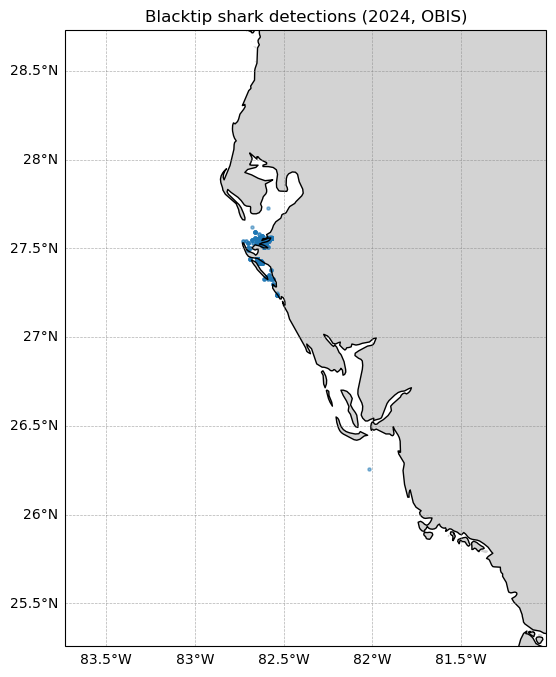

In [9]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base map
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Plot points
ax.scatter(
    df_bt["decimalLongitude"],
    df_bt["decimalLatitude"],
    s=5,
    alpha=0.5,
    transform=ccrs.PlateCarree()
)

# Set map extent
ax.set_extent([
    df_bt["decimalLongitude"].min() - 1,
    df_bt["decimalLongitude"].max() + 1,
    df_bt["decimalLatitude"].min() - 1,
    df_bt["decimalLatitude"].max() + 1
], crs=ccrs.PlateCarree())

# Add lat/lon labels
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.6,
    linestyle="--"
)

# Only label left and bottom (cartographic standard)
gl.top_labels = False
gl.right_labels = False

# Optional formatting
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

ax.set_title("Blacktip shark detections (2024, OBIS)")

plt.show()

## Receiver density map (recommended for acoustic data)

Because receivers record many detections at the same location, density maps are more informative than raw points.

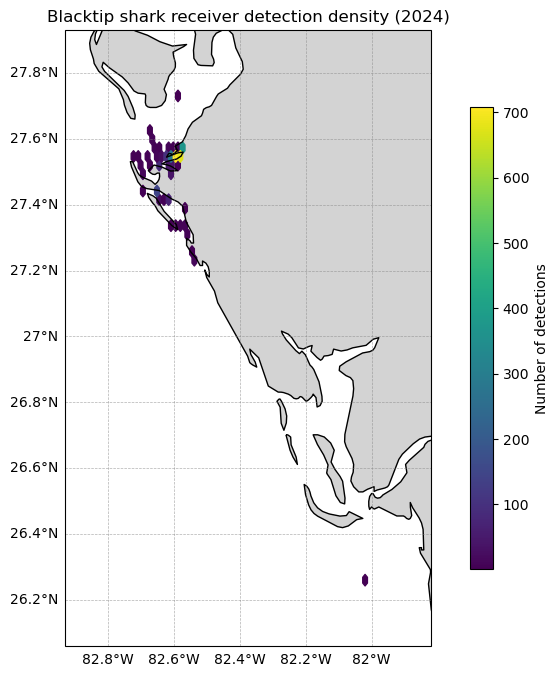

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base map
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# ---- HEXBIN DENSITY (receiver detections) ----
hb = ax.hexbin(
    df_bt["decimalLongitude"],
    df_bt["decimalLatitude"],
    gridsize=50,              # adjust for coarser/finer bins
    cmap="viridis",
    mincnt=1,
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(hb, ax=ax, shrink=0.75)
cbar.set_label("Number of detections")

pad_lon = 0.2
pad_lat = 0.2

ax.set_extent(
    [
        df_bt["decimalLongitude"].min() - pad_lon,
        df_bt["decimalLongitude"].max() + pad_lon,
        df_bt["decimalLatitude"].min() - pad_lat,
        df_bt["decimalLatitude"].max() + pad_lat,
    ],
    crs=ccrs.PlateCarree()
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.6,
    linestyle="--"
)

# Only label left and bottom
gl.top_labels = False
gl.right_labels = False

# ---- FIXED LOCATORS (regional scale) ----
gl.xlocator = mticker.MultipleLocator(0.2)   # longitude spacing
gl.ylocator = mticker.MultipleLocator(0.2)   # latitude spacing

# ---- FIXED FORMATTERS (°N / °W) ----
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Label style
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

ax.set_title("Blacktip shark receiver detection density (2024)")

plt.show()